In [1]:
library('SelectSim')
library('ggpubr')
library('tidyverse')
library('tictoc')

Loading required package: ggplot2

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 9.3 (Shamrock Pampas Cat)

Matrix products: default
BLAS/LAPACK: /mnt/ndata/arvind/envs/selectsim_R/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] tictoc_1.2.1      lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1    
 [5] dplyr_1.1.4       purrr_1.0.4       readr_2.1.5       tidyr_1.3.1      
 [9] tibble_3.2.1      tidyverse_2.0.0   ggpubr_0.6.0      ggpl

In [3]:
oncokb_run_data<-readRDS('/mnt/ptemp/arvind/selectX_qq_work/data/pan_can_tcga_run_data_sfe_onco_375.rds')
random_run<-readRDS('/mnt/ptemp/arvind/selectX_qq_work/data/pan_can_tcga_run_data_random_genes_v3.rds')
gene_list <- readRDS('/mnt/ptemp/arvind/catalouge_work/random_gene_with_matched_actual_gene_list_375.rds')

In [4]:
str(oncokb_run_data)
str(random_run)

List of 3
 $ M               :List of 2
  ..$ M  :List of 2
  .. ..$ missense  : num [1:375, 1:9082] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:375] "ABL1" "ACTG1" "ACVR1" "AJUBA" ...
  .. .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. ..$ truncating: num [1:375, 1:9082] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:375] "ABL1" "ACTG1" "ACVR1" "AJUBA" ...
  .. .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  ..$ tmb:List of 2
  .. ..$ missense  :'data.frame':	9082 obs. of  2 variables:
  .. .. ..$ sample  : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. .. ..$ mutation: num [1:9082] 56 47 40 422 214 588 14 8 19 8 ...
  .. ..$ truncating:'data.frame':	9082 obs. of  2 variables:
  .. .. ..$ sample  : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0

In [ ]:
obj_random <- selectX( M = random_run$M,
                sample.class = random_run$sample.class,
                alteration.class = random_run$alteration.class,
                n.cores = 30,
                min.freq = (0.001*9082),
                n.permut = 1000,
                lambda = 0.3,
                tao = 1,
                save.object = FALSE,
                verbose = FALSE,
                estimate_pairwise = FALSE,
                maxFDR = 0.25)

In [ ]:
saveRDS(obj_random,'../results/pan_can_tcga_frequnecy_matched_oncokb_375_random_results.rds')

In [ ]:
obj_oncokb <- selectX( M = oncokb_run_data$M,
                sample.class = oncokb_run_data$sample.class,
                alteration.class = oncokb_run_data$alteration.class,
                n.cores = 30,
                min.freq = (0.001*9082),
                n.permut = 1000,
                lambda = 0.3,
                tao = 1,
                save.object = FALSE,
                verbose = FALSE,
                estimate_pairwise = FALSE,
                maxFDR = 0.25)

In [ ]:
obj_oncokb$result %>% filter(FDR) %>% count(type)

In [ ]:
saveRDS(obj_oncokb,'../results/pan_can_tcga_frequnecy_matched_oncokb_variant_375_results.rds')

# Make the scatter plot figure for these as done in figure-1

In [5]:
pan_can_result_df_orginal<-readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/results/pan_can_tcga_oncokb_375_varaint_filtering_result_df.rds')
pan_can_random_result_df<-readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/results/pan_can_tcga_random_375_result_df.rds')

In [6]:
pan_can_result_df_orginal$log_overlap <- log10(pan_can_result_df_orginal$w_overlap + 1)
pan_can_result_df_orginal$log_r_overlap <- log10(pan_can_result_df_orginal$w_r_overlap + 1)
pan_can_result_df_orginal <- pan_can_result_df_orginal %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                    (FDR == TRUE & type=='CO') ~ 'Co-occurent ', 
                                                                    FDR == FALSE ~ "Not Significant"))



In [7]:
pan_can_result_df_orginal %>% filter(FDR) %>% dim()
pan_can_result_df_orginal %>% filter(FDR) %>% count(type)

[1] 56 25

type,n
<chr>,<int>
CO,26
ME,30


In [8]:
log_breaks <- log10(c(1, 2, 5, 10, 20, 50, 100, 200, 600))
actual_labels <- c("1", "2", "5", "10", "20", "50", "100", "200", "600")

In [9]:
plot_orgnial <- ggscatter(pan_can_result_df_orginal,
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  palette = c("forestgreen", "purple", "grey93"), 
                  repel = TRUE,
                  alpha = 0.8) + 
        annotate("text",
               x = 2,
               y = 0,
               label = "Pairs:56",
               size = 6, 
               hjust = 0) +
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle('TCGA Pan-Cancer\n 375 Genes \n Oncogenic mutations (Varaint Catalogue)') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        #scale_x_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        #scale_y_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))
        scale_x_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(600))
        ) +
        scale_y_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(600))
        )

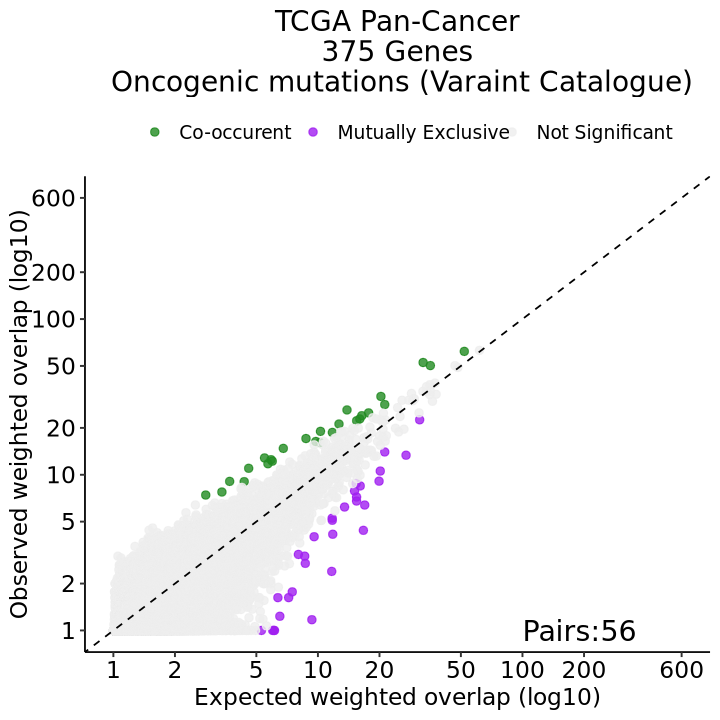

In [10]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_orgnial

In [11]:
pan_can_random_result_df$log_overlap <- log10(pan_can_random_result_df$w_overlap + 1)
pan_can_random_result_df$log_r_overlap <- log10(pan_can_random_result_df$w_r_overlap + 1)
pan_can_random_result_df <- pan_can_random_result_df %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                    (FDR == TRUE & type=='CO') ~ 'Co-occurent ', 
                                                                    FDR == FALSE ~ "Not Significant"))


In [12]:
pan_can_random_result_df %>% filter(FDR) %>% dim()

[1]  0 25

In [13]:
plot_random <- ggscatter(pan_can_random_result_df,
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  palette = c( "grey93"), 
                  repel = TRUE,
                  alpha = 0.8) + 
        annotate("text",
               x = 2,
               y = 0,
               label = "Pairs:0",
               size = 6, 
               hjust = 0)+
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle('TCGA Pan-Cancer\n 375 Random Genes \n hotspot mutations') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        #scale_x_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        #scale_y_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        scale_x_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        ) +
        scale_y_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        )

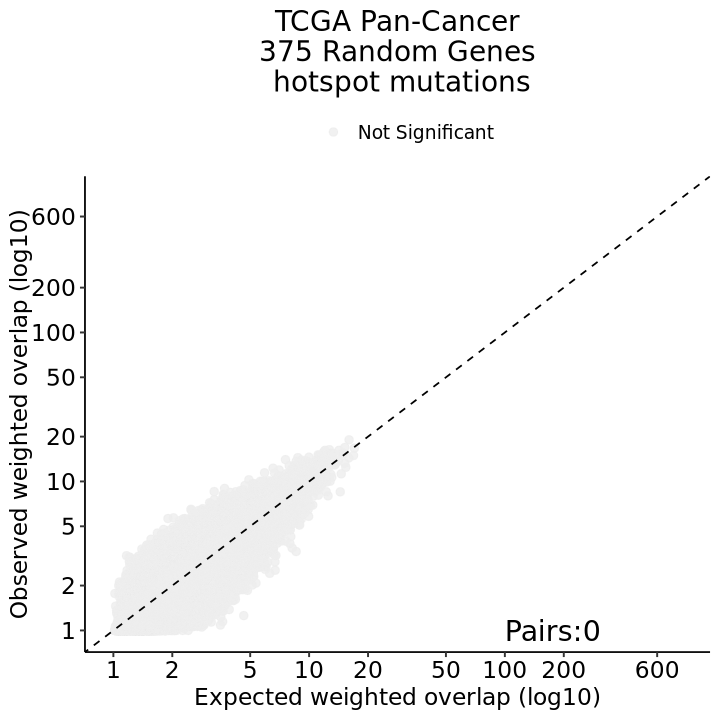

In [14]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_random

In [17]:
p_all <- ggarrange(plot_orgnial,plot_random,nrow=1,ncol=2)

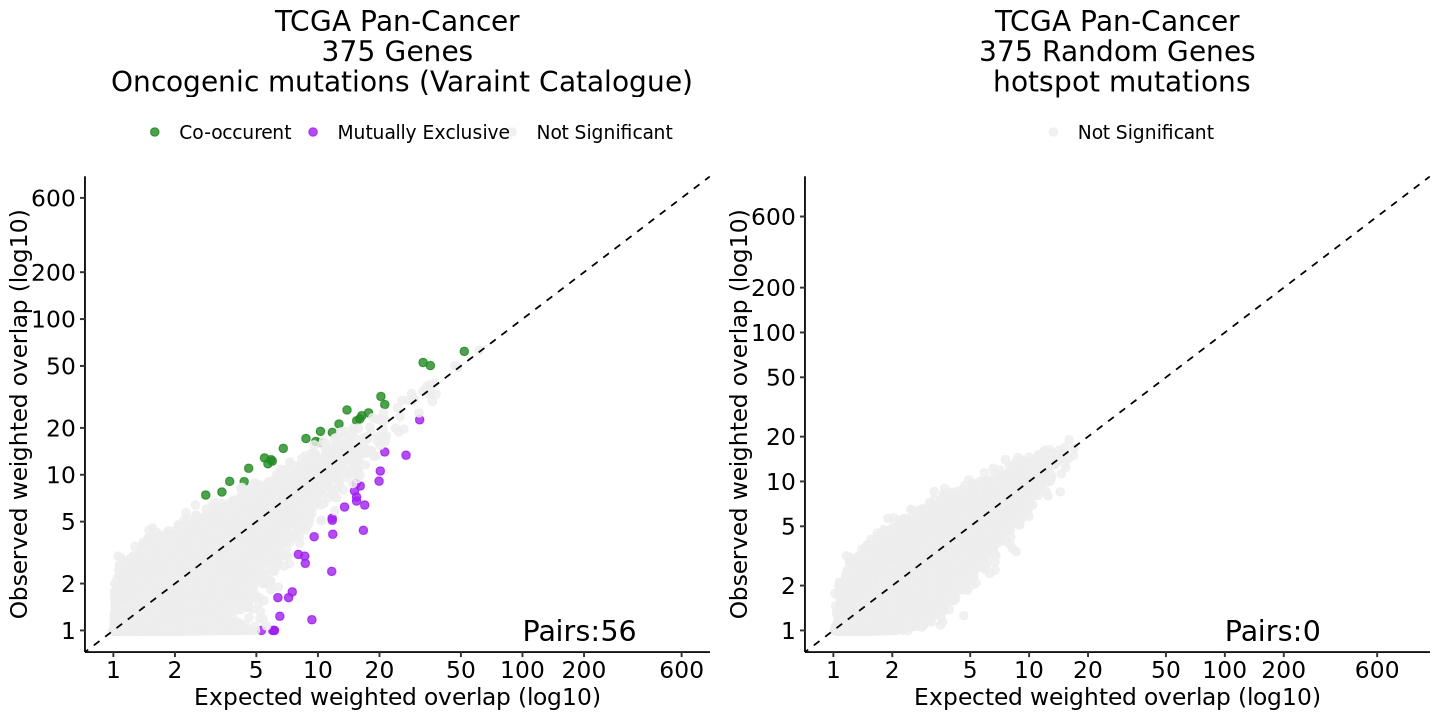

In [18]:
options(repr.plot.width=12, repr.plot.height=6)
p_all

In [ ]:
ggsave(p_all,filename = 'pan_can_tcga_oncokb_random_frequeny_matched_scatter_plot_375.pdf',device = pdf,width = 12,height = 6)